# Block 18 — LAB: Time Series — ARIMA (SOLUTION)
### Advanced Machine Learning — M&T Bank

**Dataset:** `macro_vix_monthly.csv` (unchanged since Block 17). Same chronological split. No new CSV comes out
of this lab.

Block 17 read the PACF: a sharp cutoff after lag 1, suggesting an AR(1)-shaped process. This lab builds that
model, discovers a forecasting trap (a naive multi-step forecast that quietly decays to the mean), fixes it with
a more realistic evaluation, and checks a few nearby model orders before trusting the simplest one.

Four parts:
1. **Fit the model the PACF suggested** — and see the static multi-step forecast fail in a specific, diagnosable
   way
2. **Fix the evaluation** — walk-forward, one step at a time, the way a forecast would actually be used
3. **Check nearby orders** — does anything beat the order the diagnostic plot already suggested?
4. **Residual diagnostics** — is anything still left on the table?


## Setup

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)

NAVY = "#251E4E"
PINK = "#FF1675"
GRAY = "#6b7280"
ORANGE = "#FF7B01"

# Paste the raw GitHub URL for macro_vix_monthly.csv below, then remove the leading '#':
# vix = pd.read_csv("PASTE_RAW_GITHUB_URL_HERE", sep=";", parse_dates=["date"]).set_index("date")
vix.index.freq = "MS"
series = vix["vix_close"]

split_idx = int(len(vix) * 0.8)
train, test = series.iloc[:split_idx], series.iloc[split_idx:]
print(f"Train: {len(train)} months. Test: {len(test)} months (same chronological split as Block 17).")


## Part 1 — Fit ARIMA(1,0,0), the Order the PACF Suggested

`ARIMA(p, d, q)`: `p` = autoregressive lags, `d` = differencing order, `q` = moving-average lags. Block 17 found
the series stationary (`d=0`) and a PACF that cuts off sharply after lag 1 (`p=1`). Start there.


In [2]:
model = ARIMA(train, order=(1, 0, 0)).fit()
print(model.summary().tables[1])
print(f"AIC: {model.aic:.1f}")


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.2524      2.178      8.838      0.000      14.983      23.522
ar.L1          0.8834      0.023     38.641      0.000       0.839       0.928
sigma2        12.1631      0.359     33.909      0.000      11.460      12.866
AIC: 1880.5


**The fitted AR(1) coefficient (0.883) is close to Block 17's lag-1 regression slope (0.885) — same structure,
found two different ways.** Now forecast the entire 88-month test period in one shot, the most obvious way to use
a fitted model.


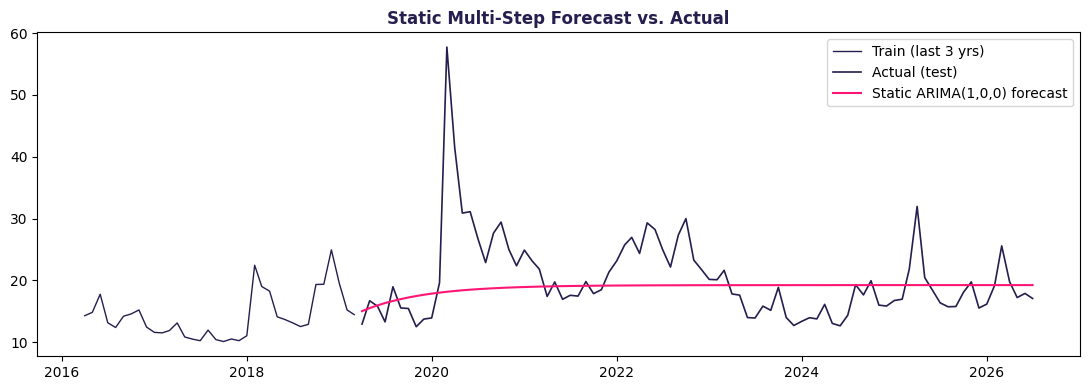

Static forecast MAE:  4.485
Static forecast RMSE: 6.887
(Block 17 naive baseline was MAE 3.192 / RMSE 5.600)


In [3]:
static_fc = model.forecast(steps=len(test))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(train.index[-36:], train.values[-36:], label="Train (last 3 yrs)", color=NAVY, linewidth=1)
ax.plot(test.index, test.values, label="Actual (test)", color=NAVY, linewidth=1.2)
ax.plot(test.index, static_fc.values, label="Static ARIMA(1,0,0) forecast", color=PINK, linewidth=1.5)
ax.legend()
ax.set_title("Static Multi-Step Forecast vs. Actual", color=NAVY, fontweight="bold")
plt.tight_layout()
plt.savefig("block18_static_forecast.png", dpi=110)
plt.show()

static_mae = np.mean(np.abs(test.values - static_fc.values))
static_rmse = np.sqrt(np.mean((test.values - static_fc.values) ** 2))
print(f"Static forecast MAE:  {static_mae:.3f}")
print(f"Static forecast RMSE: {static_rmse:.3f}")
print(f"(Block 17 naive baseline was MAE 3.192 / RMSE 5.600)")


**The static forecast is worse than Block 17's naive "next month = this month" baseline.** The chart shows why:
an AR(1) process, forecast many steps ahead with no new information, decays geometrically toward its long-run
mean — the pink line flattens out almost immediately and completely misses the market's actual moves, including
the volatility spike in the test window. This isn't a bug in ARIMA; it's a mismatch between how the model was
evaluated and how it would actually be used in production, where a new observation arrives every month.


## Part 2 — Walk-Forward Evaluation

A more realistic test: at each month in the test period, forecast only *one step ahead*, using every real
observation up through the previous month (an expanding window) — not the multi-month-old forecast from Part 1.


In [4]:
def walk_forward(order, series, split_idx):
    history = list(series.iloc[:split_idx])
    preds = []
    for t in range(split_idx, len(series)):
        m = ARIMA(history, order=order).fit()
        preds.append(m.forecast(steps=1)[0])
        history.append(series.iloc[t])  # the real value becomes known before the next forecast
    return np.array(preds)

wf_preds = walk_forward((1, 0, 0), series, split_idx)
wf_mae = np.mean(np.abs(test.values - wf_preds))
wf_rmse = np.sqrt(np.mean((test.values - wf_preds) ** 2))
print(f"Walk-forward ARIMA(1,0,0) MAE:  {wf_mae:.3f}")
print(f"Walk-forward ARIMA(1,0,0) RMSE: {wf_rmse:.3f}")


Walk-forward ARIMA(1,0,0) MAE:  2.986
Walk-forward ARIMA(1,0,0) RMSE: 5.303


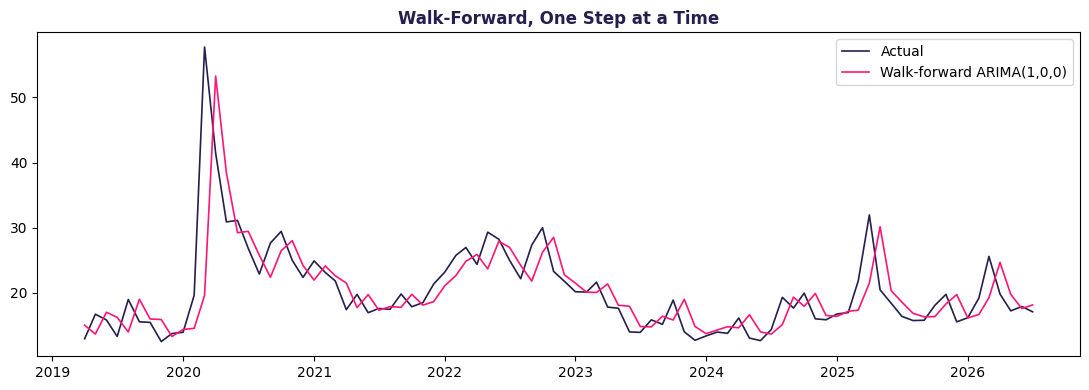

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(test.index, test.values, label="Actual", color=NAVY, linewidth=1.2)
ax.plot(test.index, wf_preds, label="Walk-forward ARIMA(1,0,0)", color=PINK, linewidth=1.2)
ax.legend()
ax.set_title("Walk-Forward, One Step at a Time", color=NAVY, fontweight="bold")
plt.tight_layout()
plt.savefig("block18_walkforward.png", dpi=110)
plt.show()


**Walk-forward evaluation lands almost exactly on Block 17's lag-1 regression (MAE 2.99 / RMSE 5.30 vs. 3.00 /
5.33) and finally, modestly, beats the naive baseline.** The lesson isn't "ARIMA is disappointing" — it's that
*how a time-series model gets evaluated has to match how it will be used*. One-step-ahead, refreshed every month,
is how a real forecasting pipeline works; a single 88-month-ahead guess almost never is.


## Part 3 — Does a Different Order Do Better?

Try a small grid of nearby orders with the same walk-forward evaluation. The PACF already made a specific
prediction in Block 17 — this checks whether it was right.


In [6]:
order_results = [{"order": (1, 0, 0), "MAE": round(wf_mae, 3), "RMSE": round(wf_rmse, 3)}]
for order in [(2, 0, 0), (1, 0, 1), (2, 0, 1)]:
    preds = walk_forward(order, series, split_idx)
    mae = np.mean(np.abs(test.values - preds))
    rmse = np.sqrt(np.mean((test.values - preds) ** 2))
    order_results.append({"order": order, "MAE": round(mae, 3), "RMSE": round(rmse, 3)})

pd.DataFrame(order_results)


,order,MAE,RMSE
0,"(1, 0, 0)",2.986,5.303
1,"(2, 0, 0)",3.045,5.462
2,"(1, 0, 1)",3.051,5.494
3,"(2, 0, 1)",3.036,5.456


**ARIMA(1,0,0) — the order read straight off the PACF chart — comes out ahead of every more complex order
tried.** Adding a second AR term or an MA term doesn't buy anything; if anything it costs a little accuracy.
Same discipline as Block 12's depth-tuned Random Forest and Block 14's ensemble combinations: more parameters
need to earn a measured improvement, and here they don't.


## Part 4 — Residual Diagnostics: Is Anything Left on the Table?

If ARIMA(1,0,0) fully captured the structure, its residuals should look like white noise — no leftover
autocorrelation. The Ljung-Box test checks this formally.


In [7]:
resid = model.resid
lb = acorr_ljungbox(resid, lags=[10], return_df=True)
print(lb)
print(f"Residual mean: {resid.mean():.3f}, residual std: {resid.std():.3f}")


      lb_stat  lb_pvalue
10  23.664223   0.008543
Residual mean: -0.010, residual std: 3.498


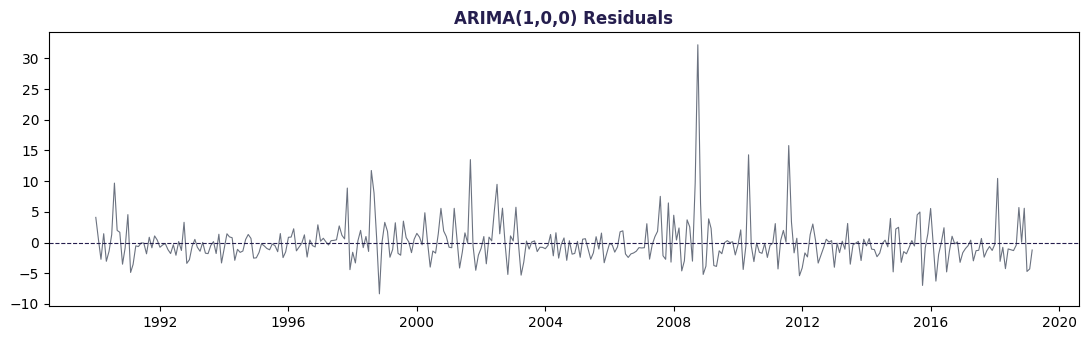

In [8]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(resid.index, resid.values, color=GRAY, linewidth=0.8)
ax.axhline(0, color=NAVY, linewidth=0.8, linestyle="--")
ax.set_title("ARIMA(1,0,0) Residuals", color=NAVY, fontweight="bold")
plt.tight_layout()
plt.savefig("block18_residuals.png", dpi=110)
plt.show()


**The Ljung-Box p-value (0.0085) rejects the "no leftover autocorrelation" null — some structure remains in the
residuals.** That's an honest, expected limitation, not a modeling mistake: VIX is well known for *volatility
clustering* (calm periods and turbulent periods each persist), a pattern in the variance of the residuals rather
than their level, which a linear ARIMA model isn't built to capture. ARIMA(1,0,0) is still a solid, defensible,
simple model that matches a linear benchmark and beats a naive one — but it isn't the last word. That gap is
exactly where Block 19's RNN picks up: a model that can learn nonlinear, state-dependent dynamics an AR(1) term
structurally cannot.


## Wrap-Up

- A static multi-step forecast decayed to the mean and lost to the naive baseline — a forecast has to be
  evaluated the way it will actually be used
- Walk-forward, one-step-ahead evaluation is where ARIMA(1,0,0) earns its keep: on par with the linear lag-1
  baseline, modestly ahead of naive
- The PACF cutoff from Block 17 correctly predicted the best-performing order among those tried — the diagnostic
  plot wasn't just decoration
- Residual diagnostics found real, honest leftover structure (volatility clustering) — a limitation, and a
  motivation for what's next

**Next: Block 19** — RNNs, built from scratch, for the nonlinear structure ARIMA can't reach.
